# Derive annual employment fluctuations for parametrising regional constraints
Felix Zaussinger | 10.11.2022

**Core Analysis Goal(s)**
1. Read country-, region-, and occupation-specific employment numbers for the last 10-15 years.
2. Analyse yearly changes, mean/sd of timeseries
3. Use to parametrise the regional constraint in the job transition simulations

**Key Insight(s)**
1.
2.
3.

In [2]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

## Read data

In [3]:
countries = [
    "AT",
    "BE",
    "CH",
    # "CY",
    "CZ",
    "DE",
    "DK",
    # "EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    # "LU",
    # "LV",
    # "NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

years = np.arange(1998, 2020)
years

array([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

In [4]:
from src.data.lfs import EuLfs

config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
eulfs = EuLfs(config=config)

##### Create data cube

In [5]:
from tqdm import tqdm

stacked_data = {}
stacked_stats = {}

cols = ["REFYEAR", "COUNTRYW", "REGIONW", "REGION", "ISCO3D", "COEFF"]
for country in tqdm(countries):
    for year in years:
        try:
            df, processing_stats = eulfs.read_filtered_file(country=country, year=year)

            stacked_data[(country, year)] = df[cols]
            stacked_stats[(country, year)] = processing_stats

        # continue if country-year file does not exist
        except FileNotFoundError as e:
            print(e)
            continue

# combine
df_stacked_data = pd.concat(list(stacked_data.values()), axis=0)

 45%|████▌     | 10/22 [02:24<03:39, 18.27s/it]

[Errno 2] No such file or directory: 'C:\\eurostat_data\\raw\\Yearly_Data\\YearlyFiles_83_2019\\_YearlyFiles\\HR_YEAR_1998_onwards\\HR1998_y.csv'
[Errno 2] No such file or directory: 'C:\\eurostat_data\\raw\\Yearly_Data\\YearlyFiles_83_2019\\_YearlyFiles\\HR_YEAR_1998_onwards\\HR1999_y.csv'
[Errno 2] No such file or directory: 'C:\\eurostat_data\\raw\\Yearly_Data\\YearlyFiles_83_2019\\_YearlyFiles\\HR_YEAR_1998_onwards\\HR2000_y.csv'
[Errno 2] No such file or directory: 'C:\\eurostat_data\\raw\\Yearly_Data\\YearlyFiles_83_2019\\_YearlyFiles\\HR_YEAR_1998_onwards\\HR2001_y.csv'


100%|██████████| 22/22 [04:48<00:00, 13.11s/it]


In [11]:
# fill nans in regionw with region
df_stacked_data["REGIONW"] = df_stacked_data["REGIONW"].fillna(
    df_stacked_data["REGION"]
)

# fill remaining nans with placeholder
df_stacked_data["REGIONW"] = df_stacked_data["REGIONW"].fillna("99")
df_stacked_data["REGION"] = df_stacked_data["REGION"].fillna("99")

# update nuts id
df_stacked_data["NUTS_ID"] = df_stacked_data["COUNTRYW"] + df_stacked_data["REGIONW"]

In [13]:
# sums for 2019
df_stacked_data_2019 = (
    df_stacked_data.loc[df_stacked_data["REFYEAR"] == "2019"]
    .groupby(["COUNTRYW", "REGIONW", "ISCO3D"])
    .sum()
)

##### Derive statistics about yearly employment changes

In [14]:
agg_dict = {"COEFF": ["min", "max", "mean", "std", "median"]}
fluctuations_over_time = df_stacked_data.groupby(
    ["COUNTRYW", "REGIONW", "ISCO3D", "REFYEAR"]
).aggregate({"COEFF": "sum"})

# YoY changes
fluctuations_over_time_YoY = fluctuations_over_time - fluctuations_over_time.groupby(
    ["COUNTRYW", "REGIONW", "ISCO3D"]
).shift(1)

# keep only yearly changes that are positive (employment influx)
fluctuations_over_time_YoY[fluctuations_over_time_YoY < 0] = np.nan

# calculate stats over time
fluctuations_stats_abs = (
    fluctuations_over_time_YoY.reset_index()
    .groupby(["COUNTRYW", "REGIONW", "ISCO3D"])
    .aggregate(agg_dict)
)
fluctuations_stats_abs.columns = [
    "_".join(col).strip() for col in fluctuations_stats_abs.columns.values
]

# add mean+sd variant
fluctuations_stats_abs["COEFF_mean+sd"] = (
    fluctuations_stats_abs["COEFF_mean"] + fluctuations_stats_abs["COEFF_std"]
)

# add 2019 data as reference
fluctuations_stats_abs["COEFF_2019"] = df_stacked_data_2019

# fill nans with 0
fluctuations_stats_abs = fluctuations_stats_abs.fillna(0)

# calculate a relative variant
fluctuations_stats_rel = fluctuations_stats_abs.copy(deep=True)
for col in fluctuations_stats_rel.columns:
    fluctuations_stats_rel[col] = fluctuations_stats_rel[col].divide(
        fluctuations_stats_rel["COEFF_2019"]
    )

# create NUTS code
fluctuations_stats_abs = fluctuations_stats_abs.reset_index()
fluctuations_stats_rel = fluctuations_stats_rel.reset_index()

fluctuations_stats_abs["NUTS_ID"] = (
    fluctuations_stats_abs["COUNTRYW"] + fluctuations_stats_abs["REGIONW"]
)
fluctuations_stats_rel["NUTS_ID"] = (
    fluctuations_stats_rel["COUNTRYW"] + fluctuations_stats_rel["REGIONW"]
)

# fluctuations_stats_abs = fluctuations_stats_abs.drop(columns=["COUNTRYW", "REGIONW"])
# fluctuations_stats_rel = fluctuations_stats_rel.drop(columns=["COUNTRYW", "REGIONW"])
#
# fluctuations_stats_abs = fluctuations_stats_abs.set_index(["NUTS_ID", "ISCO3D"])
# fluctuations_stats_rel = fluctuations_stats_rel.set_index(["NUTS_ID", "ISCO3D"])

In [15]:
from src.modelling.reskilling import ReskillingPathways

rp = ReskillingPathways()

# add zeros for missing isco groups
dfs = []
occ_id_label_mapping = rp.get_occs()

for id, df_group in fluctuations_stats_abs.groupby("NUTS_ID"):
    df_group_new = df_group.merge(
        occ_id_label_mapping, left_on="ISCO3D", right_on="code", how="right"
    )
    df_group_new["NUTS_ID"] = df_group_new["NUTS_ID"].fillna(id)
    df_group_new["COUNTRYW"] = df_group_new["COUNTRYW"].fillna(method="bfill")
    df_group_new["REGIONW"] = df_group_new["REGIONW"].fillna(method="bfill")
    df_group_new["ISCO3D"] = df_group_new["ISCO3D"].fillna(df_group_new["code"])
    # df_group_new = df_group_new.fillna(method="bfill")
    dfs.append(df_group_new)

# fill with zeros
fluctuations_stats_abs_padded = pd.concat(dfs).fillna(0)

# drop cols
fluctuations_stats_abs_padded = fluctuations_stats_abs_padded.drop(
    columns=["code", "conceptUri", "preferredLabel"]
)

In [16]:
fluctuations_stats_abs_padded

,COUNTRYW,REGIONW,ISCO3D,COEFF_min,COEFF_max,COEFF_mean,COEFF_std,COEFF_median,COEFF_mean+sd,COEFF_2019,NUTS_ID
0,AT,11,011,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AT11
1,AT,11,021,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AT11
2,AT,11,031,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AT11
3,AT,11,111,2.82,507.13,170.16,196.88,119.37,367.04,810.03,AT11
4,AT,11,112,32.60,527.82,160.63,185.93,111.09,346.56,710.01,AT11
...,...,...,...,...,...,...,...,...,...,...,...
120,UK,N0,941,"1,034.99","4,216.27","2,447.00","1,317.00","2,268.36","3,764.00","10,463.72",UKN0
121,UK,N0,951,0.00,0.00,0.00,0.00,0.00,0.00,0.00,UKN0
122,UK,N0,952,121.01,"1,312.92",960.03,563.93,"1,203.10","1,523.97",685.29,UKN0
123,UK,N0,961,290.74,"1,872.59","1,081.66","1,118.54","1,081.66","2,200.20","1,645.21",UKN0


##### YoY relative changes in employment
- on average, one ISCO-3D occupation in a NUTS-2 region can absorb up to 43% of its current employment in a year (!!!)
- Mean + 1 SD = 73% absorption capacity on average

In [17]:
fluctuations_stats_rel.dropna().describe()

,COEFF_min,COEFF_max,COEFF_mean,COEFF_std,COEFF_median,COEFF_mean+sd,COEFF_2019
count,"25,384.00","25,384.00","25,384.00","25,384.00","25,384.00","25,384.00","25,384.00"
mean,0.19,0.77,0.45,0.29,0.41,0.71,1.00
std,0.53,1.28,0.78,0.58,0.75,1.22,0.00
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,0.03,0.29,0.16,0.09,0.13,0.26,1.00
50%,0.07,0.48,0.26,0.17,0.23,0.43,1.00
75%,0.18,0.81,0.47,0.31,0.43,0.75,1.00
max,33.42,73.05,33.42,39.76,33.42,67.01,1.00


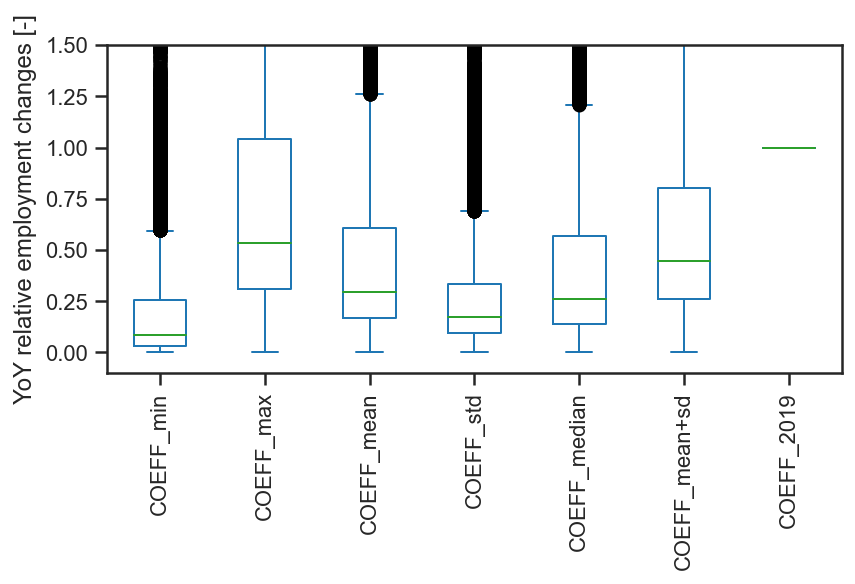

In [18]:
ax = fluctuations_stats_rel.plot.box()
ax.set_ylim(-0.1, 1.5)
plt.xticks(rotation=90)
plt.ylabel("YoY relative employment changes [-]")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "lfs_yoy_employment_fluctuations_stats_rel.png",
    ),
    dpi=300,
)

##### Save

In [19]:
utils.save_df_to_files(
    df=fluctuations_stats_abs_padded,
    output_dir=config["paths"]["processed"],
    fname_no_ext="lfs_employment_fluctuations_abs_{}_{}".format(years[0], years[-1]),
)

utils.save_df_to_files(
    df=fluctuations_stats_rel,
    output_dir=config["paths"]["processed"],
    fname_no_ext="lfs_employment_fluctuations_rel_{}_{}".format(years[0], years[-1]),
)